# §1 Individual (unfiltered) (v12 kappa=1.0) — net of costs

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

**Cost model:** every trade is charged `contracts × $5.00` round-trip (≈ $3 retail commission + 2 ticks/side slippage on MNQ at $0.50/tick). Applied to both sizing policies.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=5.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v12_k10.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v12_k10.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Applying friction: $5.00/contract RT (commission + slippage).
Loaded 10 strategies.
results_raw cache stale; rebuilding.
Running unfiltered composed_strategy_runner for each combo...


  v11_18167...


  v11_9126...


  v11_16954...


...

    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_7491...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_17806...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_28651...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
  v11_23078...


    ERROR: [Errno 2] No such file or directory: '/root/intra/data/ml/mfe/ml_dataset_v11_mfe.parquet'
Wrote cache -> _ml2_cache.pkl
ML2 portfolio trade counts: {'fixed_dollars_500': 0, 'pct5_compound': 0}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v11_18167,fixed_dollars_500,377,258.0,0.2493,-46500.29,-93.00,-2.0658,96.58,49136.82
1,v11_18167,pct5_compound,377,258.0,0.2493,-49924.39,-99.85,-2.9432,99.88,53870.86
2,v11_9126,fixed_dollars_500,469,321.0,0.2239,-14345.04,-28.69,-0.5369,64.23,34874.06
3,v11_9126,pct5_compound,469,321.0,0.2239,-48932.51,-97.87,-1.4912,99.54,65797.61
4,v11_16954,fixed_dollars_500,872,596.8,0.0596,-217633.94,-435.27,-9.0721,435.27,217633.94
5,v11_16954,pct5_compound,872,596.8,0.0596,-50000.00,-100.00,-10.6494,100.00,50000.00
6,v11_29848,fixed_dollars_500,201,137.6,0.0846,-30382.46,-60.76,-2.7416,67.72,33859.65
7,v11_29848,pct5_compound,201,137.6,0.0846,-48610.01,-97.22,-3.3046,97.91,48954.90
8,v11_17456,fixed_dollars_500,285,195.1,0.5509,-29072.59,-58.15,-2.8680,58.15,29072.59
9,v11_17456,pct5_compound,285,195.1,0.5509,-48192.67,-96.39,-3.1880,96.39,48192.67


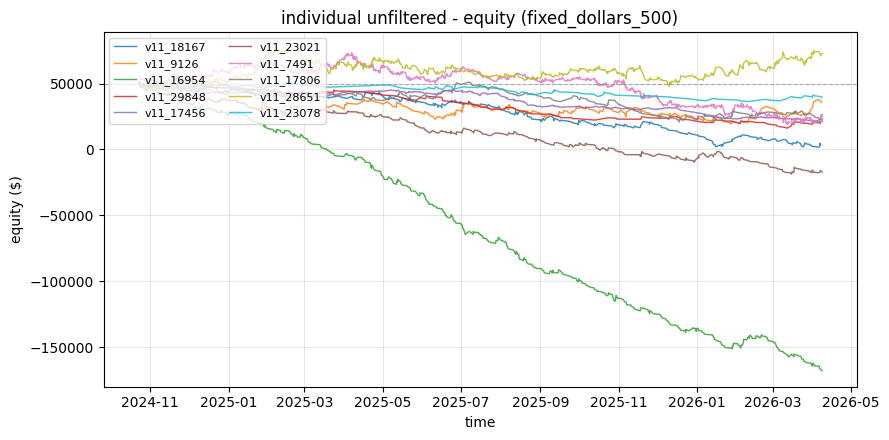

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

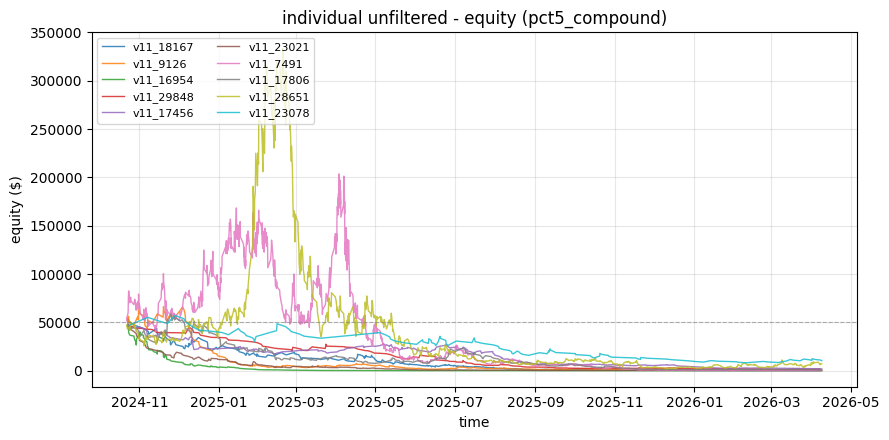

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

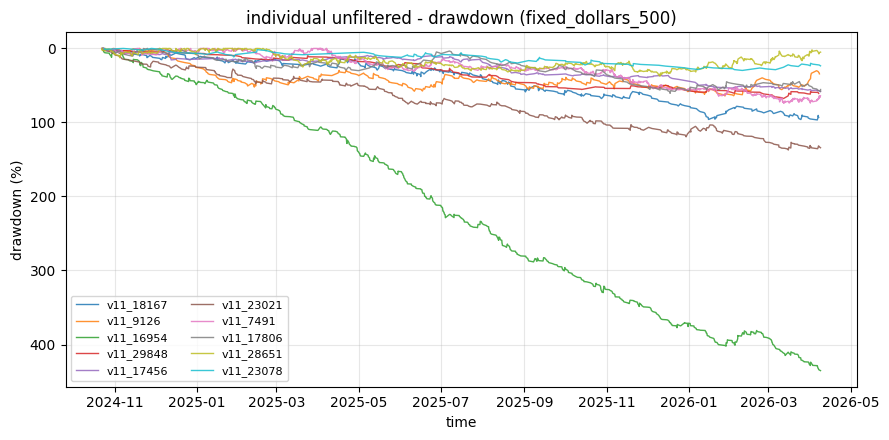

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

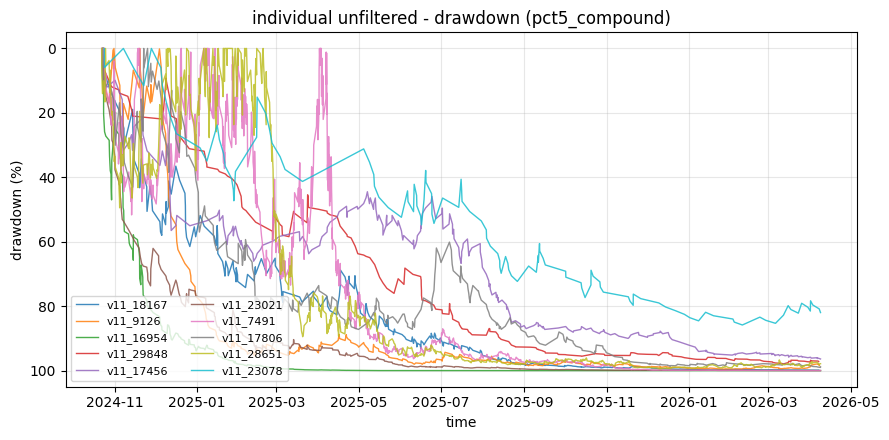

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')